In [2]:
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
from scipy import stats

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/pyproj/network.py:59: UserWarning: pyproj unable to set PROJ database path.
  _set_context_ca_bundle_path(ca_bundle_path)


# import data

In [3]:
path = '/glade/work/acruz/Caribbean_Heat_data/ERA5/'
HI_dmax = xr.open_dataset(path+'dailymax_HI.nc')
ATL3 = xr.open_dataset(path+'ATL3.nc')
ONI = xr.open_dataset(path+'ONI.nc')
CANI_EANI = xr.open_dataset(path+'CANI_EANI.nc')
HI_dmax_month_anom = xr.open_dataset(path+'HI_dmax_month_anom.nc')

/glade/u/home/acruz/.conda/envs/Caribe_Heat_AN_2026/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
RH = xr.open_dataset(path+'RHanom_during_HIdmax.nc')
T  = xr.open_dataset(path+'Tanom_during_HIdmax.nc')
U  = xr.open_dataset(path+'U_Hidmax_anom.nc')
V  = xr.open_dataset(path+'V_Hidmax_anom.nc')

In [5]:
idate = '1940-01-01'
fdate = '2025-12-31'
HI_dmax = HI_dmax['HI_daily_max'].sel(time=slice(idate, fdate))
ATL3 = ATL3['ATL3'].sel(valid_time=slice(idate, fdate))
ONI = ONI['ONI'].sel(valid_time=slice(idate, fdate))
HI_dmax_month_anom = HI_dmax_month_anom['HI_dmax_anom'].sel(time=slice(idate, fdate))
RH = RH['RHanom_during_HIdmax'].sel(time=slice(idate, fdate))
T = T['Tanom_during_HIdmax'].sel(time=slice(idate, fdate))
U = U['U10_HIdmax_anom'].sel(time=slice(idate, fdate))
V = V['V10_HIdmax_anom'].sel(time=slice(idate, fdate))
CANI = CANI_EANI['CANI'].sel(time=slice(idate, fdate))
EANI = CANI_EANI['EANI'].sel(time=slice(idate, fdate))

In [6]:
#  mix u and v to a single dataset
UV = xr.merge([U, V], compat='equals')
UV

<xarray.Dataset> Size: 2GB
Dimensions:          (latitude: 82, longitude: 121, time: 31412)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
  * time             (time) datetime64[ns] 251kB 1940-01-01 ... 2025-12-31
    month            (time) int64 251kB 1 1 1 1 1 1 1 1 ... 12 12 12 12 12 12 12
Data variables:
    U10_HIdmax_anom  (time, latitude, longitude) float32 1GB ...
    V10_HIdmax_anom  (time, latitude, longitude) float32 1GB ...

# ERS Selection

In [7]:
def me_mean(ds):
    meds = ds.resample(time='ME').mean()
    return meds


meHI_dmax = me_mean(HI_dmax)
meRH = me_mean(RH)
meT = me_mean(T)
meUV = me_mean(UV)

In [8]:
ERS = [4, 5, 6, 7]
ERS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(ERS), drop=True)
ERS_ATL3 = ATL3.where(ATL3.valid_time.dt.month.isin(ERS), drop=True)
ERS_ONI = ONI.where(ONI.valid_time.dt.month.isin(ERS), drop=True)
ERS_RH = meRH.where(meRH.time.dt.month.isin(ERS), drop=True)
ERS_T = meT.where(meT.time.dt.month.isin(ERS), drop=True)
ERS_UV = meUV.where(meUV.time.dt.month.isin(ERS), drop=True)
ERS_CANI = CANI.where(CANI.time.dt.month.isin(ERS), drop=True)
ERS_EANI = EANI.where(EANI.time.dt.month.isin(ERS), drop=True)

In [9]:
ERS_CANI_y = ERS_CANI.resample(time='YE').mean()
ERS_EANI_y = ERS_EANI.resample(time='YE').mean()
ERS_ATL3_y = ERS_ATL3.resample(valid_time='YE').mean().rename({'valid_time': 'time'})
ERS_ONI_y = ERS_ONI.resample(valid_time='YE').mean().rename({'valid_time': 'time'})

# LRS Selection

In [10]:
LRS = [8, 9, 10, 11]
LRS_HI_dmax_anom = HI_dmax_month_anom.where(HI_dmax_month_anom.time.dt.month.isin(LRS), drop=True)
LRS_ATL3 = ATL3.where(ATL3.valid_time.dt.month.isin(LRS), drop=True)
LRS_ONI = ONI.where(ONI.valid_time.dt.month.isin(LRS), drop=True)
LRS_RH = meRH.where(meRH.time.dt.month.isin(LRS), drop=True)
LRS_T = meT.where(meT.time.dt.month.isin(LRS), drop=True)
LRS_UV = meUV.where(meUV.time.dt.month.isin(LRS), drop=True)
LRS_CANI = CANI.where(CANI.time.dt.month.isin(LRS), drop=True)
LRS_EANI = EANI.where(EANI.time.dt.month.isin(LRS), drop=True)

In [11]:
LRS_CANI_y = LRS_CANI.resample(time='YE').mean()
LRS_EANI_y = LRS_EANI.resample(time='YE').mean()
LRS_ATL3_y = LRS_ATL3.resample(valid_time='YE').mean().rename({'valid_time': 'time'})
LRS_ONI_y = LRS_ONI.resample(valid_time='YE').mean().rename({'valid_time': 'time'})

# Phases

In [12]:
def niño(ds):
    return ds >= 0.5


def niña(ds):
    return ds <= -0.5


def neutral(ds):
    return ((ds > -0.5) & (ds < 0.5) )

# <span style="color:orange">Phase convo<span/>

## Warm Atlantic and Warm Pacific

In [13]:
def ww_cond(ds1, ds2):
    return (niño(ds1) & (niño(ds2)))

In [14]:
ATL3o_ONIo_ERSyears = ERS_ATL3_y.time.dt.year.where(ww_cond(ERS_ATL3_y, ERS_ONI_y), drop=True)
ATL3o_ONIo_ERSyears

<xarray.DataArray 'year' (time: 2)> Size: 16B
array([1998., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 16B 1998-12-31 2024-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [15]:
ATL3o_ONIo_LRSyears = LRS_ATL3_y.time.dt.year.where(ww_cond(LRS_ATL3_y, LRS_ONI_y), drop=True)
ATL3o_ONIo_LRSyears

<xarray.DataArray 'year' (time: 3)> Size: 24B
array([1968., 1987., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 24B 1968-12-31 1987-12-31 2023-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [16]:
CANo_ONIo_ERSy = ERS_CANI_y.time.dt.year.where(ww_cond(ERS_CANI_y, ERS_ONI_y), drop=True)
CANo_ONIo_ERSy

<xarray.DataArray 'year' (time: 6)> Size: 48B
array([1940., 1966., 1969., 1998., 2019., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 48B 1940-12-31 1966-12-31 ... 2024-12-31

In [17]:
CANo_ONIo_LRSy = LRS_CANI_y.time.dt.year.where(ww_cond(LRS_CANI_y, LRS_ONI_y), drop=True)
CANo_ONIo_LRSy

<xarray.DataArray 'year' (time: 8)> Size: 64B
array([1940., 1941., 1951., 1953., 1968., 1987., 2006., 2023.])
Coordinates:
  * time     (time) datetime64[ns] 64B 1940-12-31 1941-12-31 ... 2023-12-31

In [18]:
EANo_ONIo_ERSy = ERS_EANI_y.time.dt.year.where(ww_cond(ERS_EANI_y, ERS_ONI_y), drop=True)
EANo_ONIo_ERSy

<xarray.DataArray 'year' (time: 5)> Size: 40B
array([1966., 1969., 1987., 1998., 2024.])
Coordinates:
  * time     (time) datetime64[ns] 40B 1966-12-31 1969-12-31 ... 2024-12-31

## Cold Atlantic and Warm Pacific

In [19]:
def wc_cond(ds1, ds2):
    return (niño(ds1) & (niña(ds2)))

In [20]:
ATL3a_ONIo_ERSy = ERS_ATL3_y.time.dt.year.where(wc_cond(ERS_ATL3_y, ERS_ONI_y), drop=True)
ATL3a_ONIo_LRSy = LRS_ATL3_y.time.dt.year.where(wc_cond(LRS_ATL3_y, LRS_ONI_y), drop=True)

In [21]:
ATL3a_ONIo_ERSy

<xarray.DataArray 'year' (time: 5)> Size: 40B
array([1984., 1988., 1996., 1999., 2008.])
Coordinates:
  * time     (time) datetime64[ns] 40B 1984-12-31 1988-12-31 ... 2008-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [22]:
ATL3a_ONIo_LRSy

<xarray.DataArray 'year' (time: 5)> Size: 40B
array([1984., 1988., 1998., 1999., 2010.])
Coordinates:
  * time     (time) datetime64[ns] 40B 1984-12-31 1988-12-31 ... 2010-12-31
Attributes:
    long_name:      time
    standard_name:  time

In [23]:
CANa_ONIo_ERS = ERS_CANI_y.time.dt.year.where(wc_cond(ERS_CANI_y, ERS_ONI_y), drop=True)
CANa_ONIo_LRS = LRS_CANI_y.time.dt.year.where(wc_cond(LRS_CANI_y, LRS_ONI_y), drop=True)
EANa_ONIo_ERS = ERS_EANI_y.time.dt.year.where(wc_cond(ERS_EANI_y, ERS_ONI_y), drop=True)
EANa_ONIo_LRS = LRS_EANI_y.time.dt.year.where(wc_cond(LRS_EANI_y, LRS_ONI_y), drop=True)

## Warm Atlantic and Cold Pacific

In [24]:
ATL3o_ONIa_ERS = ERS_ATL3_y.time.dt.year.where(wc_cond(ERS_ONI_y, ERS_ATL3_y), drop=True)
ATL3o_ONIa_LRS = LRS_ATL3_y.time.dt.year.where(wc_cond(LRS_ONI_y, LRS_ATL3_y), drop=True)

In [25]:
CANo_ONIa_ERS = ERS_CANI_y.time.dt.year.where(wc_cond(ERS_ONI_y, ERS_CANI_y), drop=True)
CANo_ONIa_LRS = LRS_CANI_y.time.dt.year.where(wc_cond(LRS_ONI_y, LRS_CANI_y), drop=True)
EANo_ONIa_ERS = ERS_EANI_y.time.dt.year.where(wc_cond(ERS_ONI_y, ERS_EANI_y), drop=True)
EANo_ONIa_LRS = LRS_EANI_y.time.dt.year.where(wc_cond(LRS_ONI_y, LRS_EANI_y), drop=True)

# <span style="color:orange">Warm ATL3 and Warm ONI<span/>

## phases composites

In [26]:
def get_comp(var_ds, years):
    var_comp = var_ds.where(var_ds.time.dt.year.isin(years.values), drop=True)
    return var_comp.mean('time')

### ERS +ATL3 and +ONI

In [27]:
ERS_HIdmax_comp_ATL3o_ONIo = get_comp(ERS_HI_dmax_anom, ATL3o_ONIo_ERSyears)
ERS_T_comp_ATL3o_ONIo = get_comp(ERS_T, ATL3o_ONIo_ERSyears)
ERS_UV_comp_ATL3o_ONIo = get_comp(ERS_UV, ATL3o_ONIo_ERSyears)
ERS_RH_comp_ATL3o_ONIo = get_comp(ERS_RH, ATL3o_ONIo_ERSyears)

In [28]:
ERS_UV_comp_ATL3o_ONIo

<xarray.Dataset> Size: 81kB
Dimensions:          (latitude: 82, longitude: 121)
Coordinates:
  * latitude         (latitude) float64 656B 7.75 8.0 8.25 ... 27.5 27.75 28.0
  * longitude        (longitude) float64 968B -89.0 -88.75 ... -59.25 -59.0
Data variables:
    U10_HIdmax_anom  (latitude, longitude) float32 40kB -0.1204 ... 0.1809
    V10_HIdmax_anom  (latitude, longitude) float32 40kB -0.5376 ... 0.1507

### LRS +ATL3 and +ONI

In [29]:
LRS_HIdmax_comp_ATL3o_ONIo = get_comp(LRS_HI_dmax_anom, ATL3o_ONIo_LRSyears)
LRS_T_comp_ATL3o_ONIo = get_comp(LRS_T, ATL3o_ONIo_LRSyears)
LRS_UV_comp_ATL3o_ONIo = get_comp(LRS_UV, ATL3o_ONIo_LRSyears)
LRS_RH_comp_ATL3o_ONIo = get_comp(LRS_RH, ATL3o_ONIo_LRSyears)

## Random Composites

In [30]:
def random_comp_dist(var_ds, comp_size,iter=1000, sig=0.90):
    draw = np.random.choice(var_ds.time, size=(iter, comp_size), replace=True)
    idx = xr.DataArray(draw, dims=['iteration', 'sample'], coords={'iteration': np.arange(iter)})
    
    rand_comp_dist = var_ds.sel(time=idx).mean('sample')

    l_sig = (1 - sig) / 2
    h_sig = 1 - l_sig
    results = rand_comp_dist.quantile([l_sig, h_sig], dim='iteration')
    return results

### ERS

In [31]:
sig_threshold = 0.90

In [32]:
ERS_HIdmax_MCBS = random_comp_dist(ERS_HI_dmax_anom, ATL3o_ONIo_ERSyears.sizes['time'], sig=sig_threshold)
ERS_T_MCBS = random_comp_dist(ERS_T, ATL3o_ONIo_ERSyears.sizes['time'], sig=sig_threshold)
ERS_RH_MCBS = random_comp_dist(ERS_RH, ATL3o_ONIo_ERSyears.sizes['time'], sig=sig_threshold)

ERS_U_MCBS = random_comp_dist(ERS_UV['U10_HIdmax_anom'], ATL3o_ONIo_ERSyears.sizes['time'], sig=sig_threshold)
ERS_V_MCBS = random_comp_dist(ERS_UV['V10_HIdmax_anom'], ATL3o_ONIo_ERSyears.sizes['time'], sig=sig_threshold)

### LRS

In [33]:
LRS_HIdmax_MCBS = random_comp_dist(LRS_HI_dmax_anom, ATL3o_ONIo_LRSyears.sizes['time'], sig=sig_threshold)
LRS_T_MCBS = random_comp_dist(LRS_T, ATL3o_ONIo_LRSyears.sizes['time'], sig=sig_threshold)
LRS_RH_MCBS = random_comp_dist(LRS_RH, ATL3o_ONIo_LRSyears.sizes['time'], sig=sig_threshold)

LRS_U_MCBS = random_comp_dist(LRS_UV['U10_HIdmax_anom'], ATL3o_ONIo_LRSyears.sizes['time'], sig=sig_threshold)
LRS_V_MCBS = random_comp_dist(LRS_UV['V10_HIdmax_anom'], ATL3o_ONIo_LRSyears.sizes['time'], sig=sig_threshold)

## Filter Reanalysis by percentile of random composite

In [34]:
def sel_sig(ds, filter):
    # takes dataset and qunatiles from random distribution of composites
    l_bound = filter.sel(quantile=0.05, method='nearest')
    h_bound = filter.sel(quantile=0.95, method='nearest')
    sig_mask = (ds < l_bound) | (ds > h_bound)
    sig_ds = ds.where(sig_mask)
    return sig_ds

## Plots

### ERS

In [35]:
ERS_HI_sig = sel_sig(ERS_HIdmax_comp_ATL3o_ONIo, ERS_HIdmax_MCBS)
ERS_T_sig = sel_sig(ERS_T_comp_ATL3o_ONIo, ERS_T_MCBS)
ERS_RH_sig = sel_sig(ERS_RH_comp_ATL3o_ONIo, ERS_RH_MCBS)

In [37]:
ERS_U_sig = sel_sig(ERS_UV_comp_ATL3o_ONIo['U10_HIdmax_anom'], ERS_U_MCBS)
ERS_V_sig = sel_sig(ERS_UV_comp_ATL3o_ONIo['V10_HIdmax_anom'], ERS_V_MCBS)
ERS_UV_sig = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with +ATL3 and +ONI (n=2y, Sig=90.0%)')

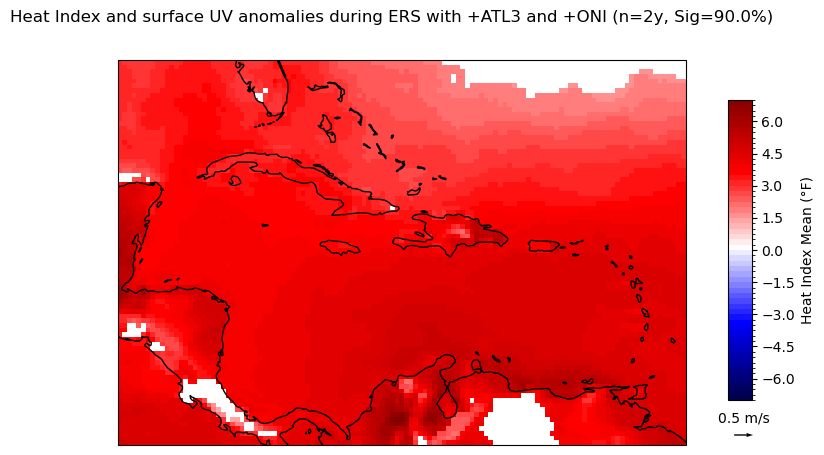

In [38]:
ERS_HI_sig_plot = ERS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with +ATL3 and +ONI (n={ATL3o_ONIo_ERSyears.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with +ATL3 and +ONI (n=2y, Sig=90.0%)')

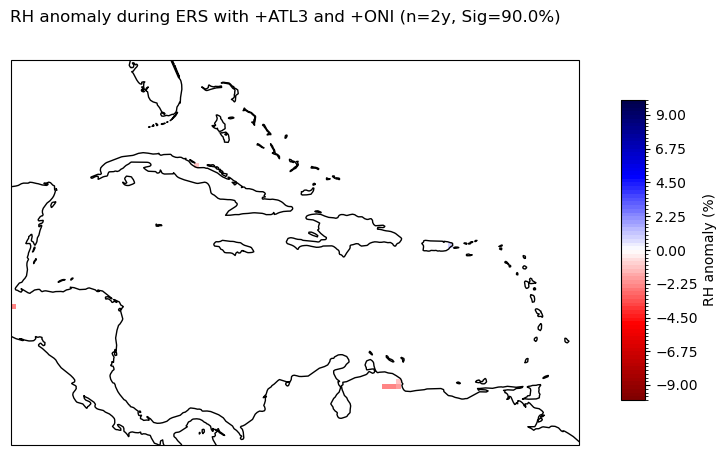

In [39]:
ERS_RH_sig_plot = ERS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with +ATL3 and +ONI (n={ATL3o_ONIo_ERSyears.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with +ATL3 and +ONI (n=2y, Sig=90.0%)')

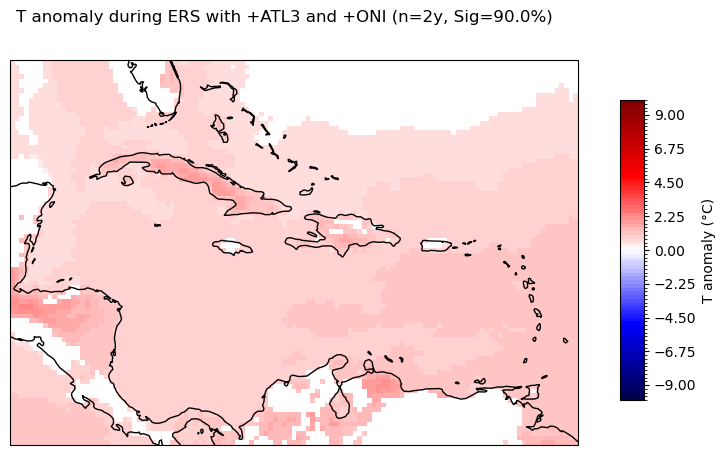

In [40]:
ERS_T_sig_plot = ERS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with +ATL3 and +ONI (n={ATL3o_ONIo_ERSyears.sizes['time']}y, Sig={sig_threshold*100}%)')

### LRS

In [41]:
LRS_HI_sig = sel_sig(LRS_HIdmax_comp_ATL3o_ONIo, LRS_HIdmax_MCBS)
LRS_T_sig = sel_sig(LRS_T_comp_ATL3o_ONIo, LRS_T_MCBS)
LRS_RH_sig = sel_sig(LRS_RH_comp_ATL3o_ONIo, LRS_RH_MCBS)

In [42]:
LRS_U_sig = sel_sig(LRS_UV_comp_ATL3o_ONIo['U10_HIdmax_anom'], LRS_U_MCBS)
LRS_V_sig = sel_sig(LRS_UV_comp_ATL3o_ONIo['V10_HIdmax_anom'], LRS_V_MCBS)
LRS_UV_sig = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with +ATL3 and +ONI (n=3y, Sig=90.0%)')

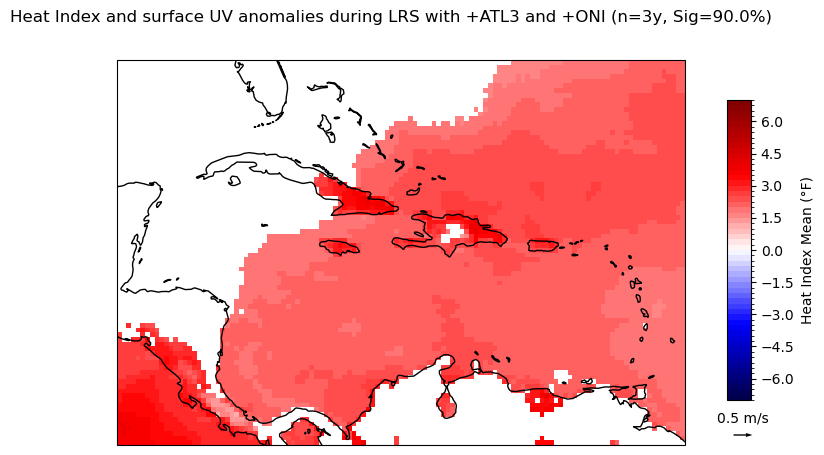

In [43]:
LRS_HI_sig_plot = LRS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with +ATL3 and +ONI (n={ATL3o_ONIo_LRSyears.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with +ATL3 and +ONI (n=3y, Sig=90.0%)')

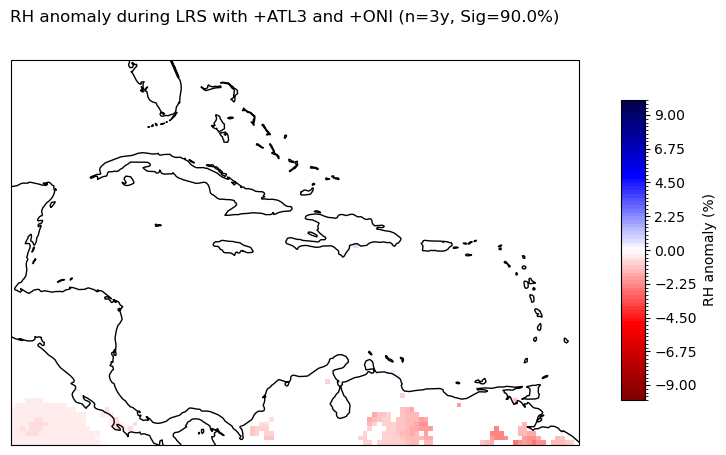

In [44]:
LRS_RH_sig_plot = LRS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with +ATL3 and +ONI (n={ATL3o_ONIo_LRSyears.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with +ATL3 and +ONI (n=3y, Sig=90.0%)')

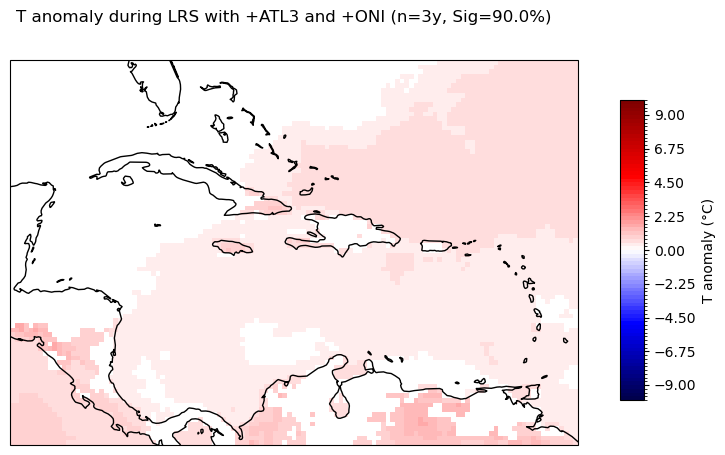

In [46]:
LRS_T_sig_plot = LRS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with +ATL3 and +ONI (n={ATL3o_ONIo_LRSyears.sizes['time']}y, Sig={sig_threshold*100}%)')

# <span style="color:orange">Warm ATL3 and Cold ONI<span/>

## Phase Comps

### <span style="color:orange"> ERS <span/>

In [47]:
ERS_HIdmax_comp_ATL3o_ONIa = get_comp(ERS_HI_dmax_anom, ATL3o_ONIa_ERS)
ERS_UV_comp_ATL3o_ONIa = get_comp(ERS_UV, ATL3o_ONIa_ERS)
ERS_T_comp_ATL3o_ONIa = get_comp(ERS_T, ATL3o_ONIa_ERS)
ERS_RH_comp_ATL3o_ONIa = get_comp(ERS_RH, ATL3o_ONIa_ERS)

### <span style="color:orange"> LRS <span/>

In [48]:
LRS_HIdmax_comp_ATL3o_ONIa = get_comp(LRS_HI_dmax_anom, ATL3o_ONIa_LRS)
LRS_UV_comp_ATL3o_ONIa = get_comp(LRS_UV, ATL3o_ONIa_LRS)
LRS_T_comp_ATL3o_ONIa = get_comp(LRS_T, ATL3o_ONIa_LRS)
LRS_RH_comp_ATL3o_ONIa = get_comp(LRS_RH, ATL3o_ONIa_LRS)

## Random Composites

### <span style="color:orange"> ERS <span/>

In [49]:
samples = ATL3o_ONIa_ERS.sizes['time']
ERS_HIdmax_MCBS_AoPa = random_comp_dist(ERS_HI_dmax_anom, samples, sig=sig_threshold)
ERS_T_MCBS_AoPa = random_comp_dist(ERS_T, samples, sig=sig_threshold)
ERS_RH_MCBS_AoPa = random_comp_dist(ERS_RH, samples, sig=sig_threshold)

ERS_U_MCBS_AoPa = random_comp_dist(ERS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)
ERS_V_MCBS_AoPa = random_comp_dist(ERS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)

### <span style="color:orange"> LRS <span/>

In [50]:
samples = ATL3o_ONIa_LRS.sizes['time']

LRS_HIdmax_MCBS_AoPa = random_comp_dist(LRS_HI_dmax_anom, samples, sig=sig_threshold)
LRS_T_MCBS_AoPa = random_comp_dist(LRS_T, samples, sig=sig_threshold)
LRS_RH_MCBS_AoPa = random_comp_dist(LRS_RH, samples, sig=sig_threshold)

LRS_U_MCBS_AoPa = random_comp_dist(LRS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)
LRS_V_MCBS_AoPa = random_comp_dist(LRS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)

## Filter significance

### <span style="color:orange"> ERS <span/>

In [51]:
ERS_HI_sig = sel_sig(ERS_HIdmax_comp_ATL3o_ONIa, ERS_HIdmax_MCBS_AoPa)
ERS_T_sig = sel_sig(ERS_T_comp_ATL3o_ONIa, ERS_T_MCBS_AoPa)
ERS_RH_sig = sel_sig(ERS_RH_comp_ATL3o_ONIa, ERS_RH_MCBS_AoPa)

ERS_U_sig = sel_sig(ERS_UV_comp_ATL3o_ONIa['U10_HIdmax_anom'], ERS_U_MCBS_AoPa)
ERS_V_sig = sel_sig(ERS_UV_comp_ATL3o_ONIa['V10_HIdmax_anom'], ERS_V_MCBS_AoPa)
ERS_UV_sig = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

### <span style="color:orange"> LRS <span/>

In [52]:
LRS_HI_sig = sel_sig(LRS_HIdmax_comp_ATL3o_ONIa, LRS_HIdmax_MCBS_AoPa)
LRS_T_sig = sel_sig(LRS_T_comp_ATL3o_ONIa, LRS_T_MCBS_AoPa)
LRS_RH_sig = sel_sig(LRS_RH_comp_ATL3o_ONIa, LRS_RH_MCBS_AoPa)

LRS_U_sig = sel_sig(LRS_UV_comp_ATL3o_ONIa['U10_HIdmax_anom'], LRS_U_MCBS_AoPa)
LRS_V_sig = sel_sig(LRS_UV_comp_ATL3o_ONIa['V10_HIdmax_anom'], LRS_V_MCBS_AoPa)
LRS_UV_sig = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

## Plots

### <span style="color:orange"> ERS <span/>

#### HI

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with +ATL3 and -ONI (n=4y, Sig=90.0%)')

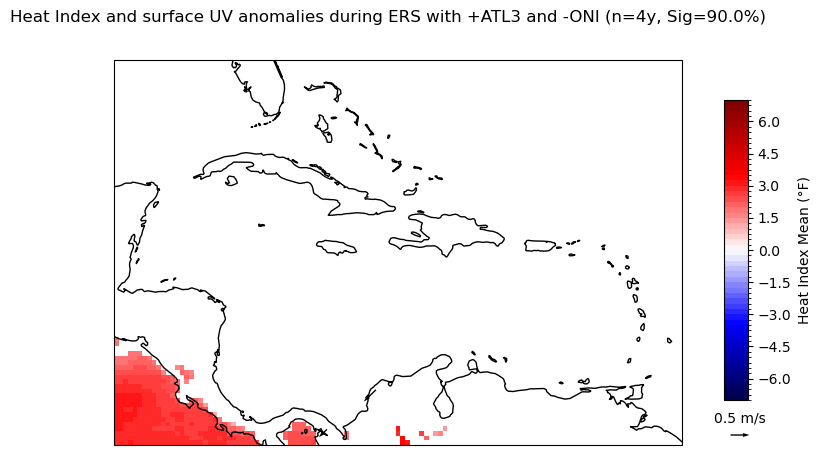

In [71]:
ERS_HI_sig_plot = ERS_HI_sig.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with +ATL3 and -ONI (n={ATL3o_ONIa_ERS.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with +ATL3 and -ONI (n=4y, Sig=90.0%)')

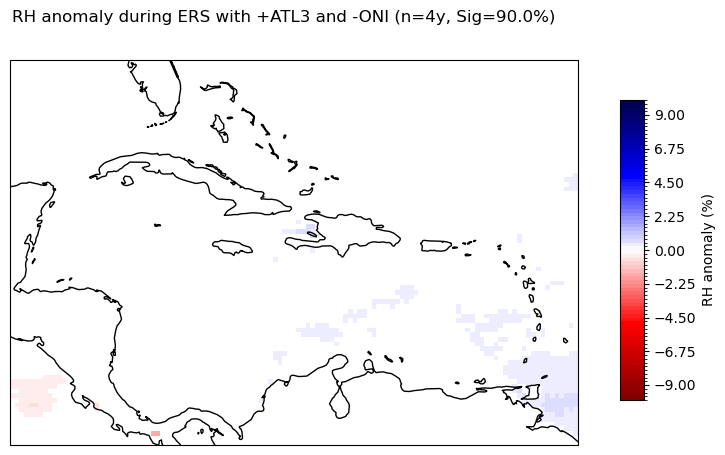

In [72]:
ERS_RH_sig_plot = ERS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with +ATL3 and -ONI (n={ATL3o_ONIa_ERS.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with +ATL3 and -ONI (n=4y, Sig=90.0%)')

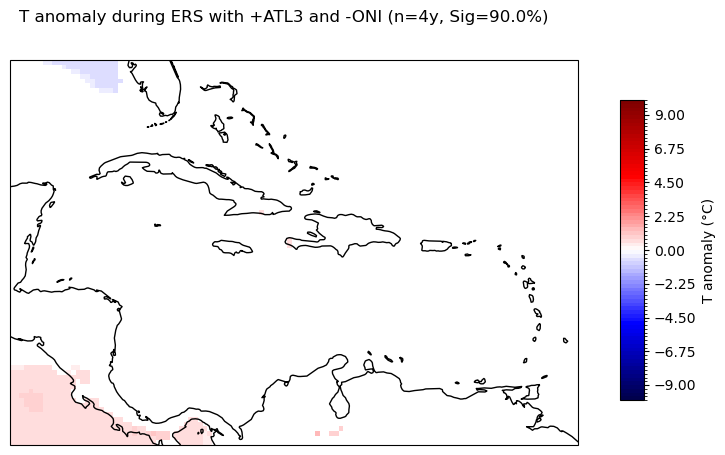

In [73]:
ERS_T_sig_plot = ERS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with +ATL3 and -ONI (n={ATL3o_ONIa_ERS.sizes['time']}y, Sig={sig_threshold*100}%)')

### <span style="color:orange"> LRS <span/>

#### HI

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with +ATL3 and -ONI (n=2y, Sig=90.0%)')

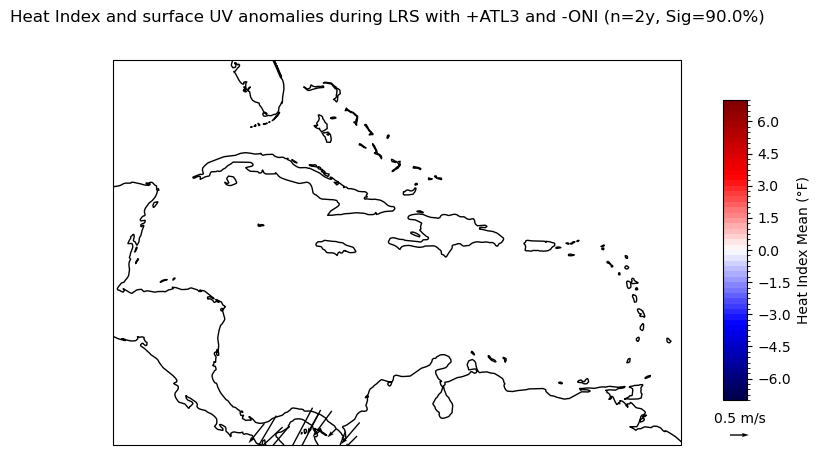

In [74]:
LRS_HI_sig_plot = LRS_HI_sig.plot(figsize=(8, 5), levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with +ATL3 and -ONI (n={ATL3o_ONIa_LRS.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with +ATL3 and -ONI (n=2y, Sig=90.0%)')

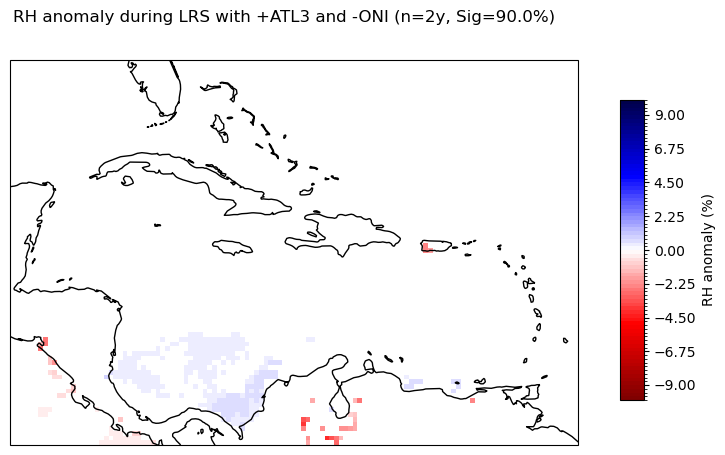

In [75]:
LRS_RH_sig_plot = LRS_RH_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with +ATL3 and -ONI (n={ATL3o_ONIa_LRS.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with +ATL3 and -ONI (n=2y, Sig=90.0%)')

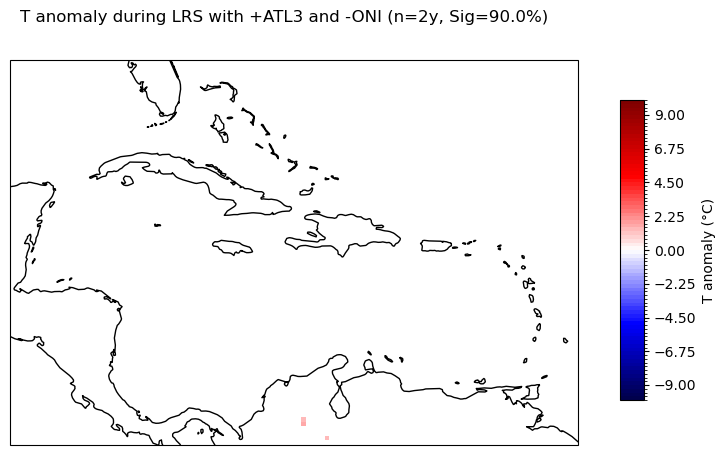

In [76]:
LRS_T_sig_plot = LRS_T_sig.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with +ATL3 and -ONI (n={ATL3o_ONIa_LRS.sizes['time']}y, Sig={sig_threshold*100}%)')

# <span style="color:orange">Warm CAN and Warm ONI<span/>

## Phase Comps

### <span style="color:orange"> ERS <span/>

In [59]:
ERS_HIdmax_comp_CANo_ONIo = get_comp(ERS_HI_dmax_anom, CANo_ONIo_ERSy)
ERS_T_comp_CANo_ONIo = get_comp(ERS_T, CANo_ONIo_ERSy)
ERS_UV_comp_CANo_ONIo = get_comp(ERS_UV, CANo_ONIo_ERSy)
ERS_RH_comp_CANo_ONIo = get_comp(ERS_RH, CANo_ONIo_ERSy)

### <span style="color:orange"> LRS <span/>

In [60]:
LRS_HIdmax_comp_CANo_ONIo = get_comp(LRS_HI_dmax_anom, CANo_ONIo_LRSy)
LRS_UV_comp_CANo_ONIo = get_comp(LRS_UV, CANo_ONIo_LRSy)
LRS_T_comp_CANo_ONIo = get_comp(LRS_T, CANo_ONIo_LRSy)
LRS_RH_comp_CANo_ONIo = get_comp(LRS_RH, CANo_ONIo_LRSy)

## Random Composites

### <span style="color:orange"> ERS <span/>

In [61]:
samples = CANo_ONIo_ERSy.sizes['time']

ERS_HIdmax_MCBS_CoPo = random_comp_dist(ERS_HI_dmax_anom, samples, sig=sig_threshold)
ERS_T_MCBS_CoPo = random_comp_dist(ERS_T, samples, sig=sig_threshold)
ERS_RH_MCBS_CoPo = random_comp_dist(ERS_RH, samples, sig=sig_threshold)

ERS_U_MCBS_CoPo = random_comp_dist(ERS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)
ERS_V_MCBS_CoPo = random_comp_dist(ERS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)

### <span style="color:orange"> LRS <span/>

In [62]:
samples = CANo_ONIo_LRSy.sizes['time']

LRS_HIdmax_MCBS_CoPo = random_comp_dist(LRS_HI_dmax_anom, samples, sig=sig_threshold)
LRS_T_MCBS_CoPo = random_comp_dist(LRS_T, samples, sig=sig_threshold)
LRS_RH_MCBS_CoPo = random_comp_dist(LRS_RH, samples, sig=sig_threshold)

LRS_U_MCBS_CoPo = random_comp_dist(LRS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)
LRS_V_MCBS_CoPo = random_comp_dist(LRS_UV['U10_HIdmax_anom'], samples, sig=sig_threshold)

## Filter Significance

### <span style="color:orange"> ERS <span/>

In [63]:
ERS_HI_sig_CoPo = sel_sig(ERS_HIdmax_comp_CANo_ONIo, ERS_HIdmax_MCBS_CoPo)
ERS_T_sig_CoPo = sel_sig(ERS_T_comp_CANo_ONIo, ERS_T_MCBS_CoPo)
ERS_RH_sig_CoPo = sel_sig(ERS_RH_comp_CANo_ONIo, ERS_RH_MCBS_CoPo)

ERS_U_sig = sel_sig(ERS_UV_comp_CANo_ONIo['U10_HIdmax_anom'], ERS_U_MCBS_CoPo)
ERS_V_sig = sel_sig(ERS_UV_comp_CANo_ONIo['V10_HIdmax_anom'], ERS_V_MCBS_CoPo)
ERS_UV_sig_CoPo = xr.merge([ERS_U_sig.rename('U'), ERS_V_sig.rename('V')])

### <span style="color:orange"> LRS <span/>

In [64]:
LRS_HI_sig_CoPo = sel_sig(LRS_HIdmax_comp_CANo_ONIo, LRS_HIdmax_MCBS_CoPo)
LRS_T_sig_CoPo = sel_sig(LRS_T_comp_CANo_ONIo, LRS_T_MCBS_CoPo)
LRS_RH_sig_CoPo = sel_sig(LRS_RH_comp_CANo_ONIo, LRS_RH_MCBS_CoPo)

LRS_U_sig = sel_sig(LRS_UV_comp_CANo_ONIo['U10_HIdmax_anom'], LRS_U_MCBS_CoPo)
LRS_V_sig = sel_sig(LRS_UV_comp_CANo_ONIo['V10_HIdmax_anom'], LRS_V_MCBS_CoPo)
LRS_UV_sig_CoPo = xr.merge([LRS_U_sig.rename('U'), LRS_V_sig.rename('V')])

## Plots

### <span style="color: orange"> ERS <span/>

#### HI

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during ERS with +CAN and +ONI (n=6y, Sig=90.0%)')

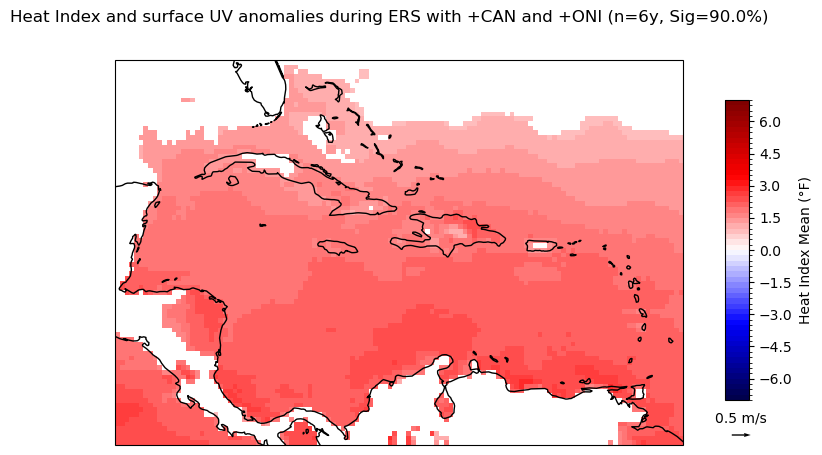

In [65]:
ERS_HI_sig_plot = ERS_HI_sig_CoPo.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = ERS_UV_sig_CoPo.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = ERS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

ERS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during ERS with +CAN and +ONI (n={CANo_ONIo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during ERS with +CAN and +ONI (n=6y, Sig=90.0%)')

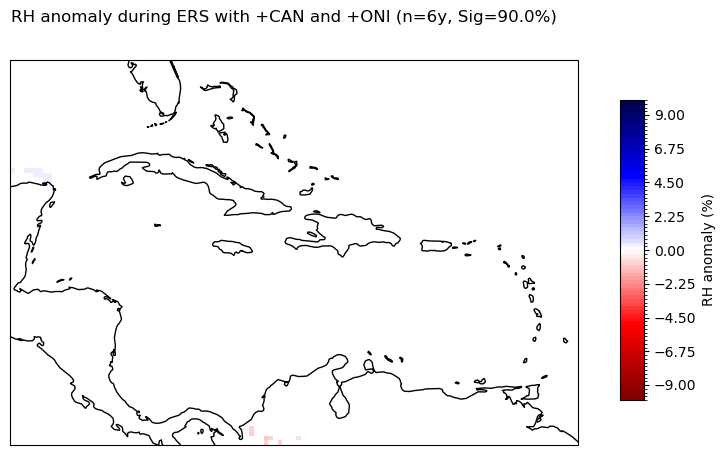

In [66]:
ERS_RH_sig_plot = ERS_RH_sig_CoPo.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

ERS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during ERS with +CAN and +ONI (n={CANo_ONIo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during ERS with +CAN and +ONI (n=6y, Sig=90.0%)')

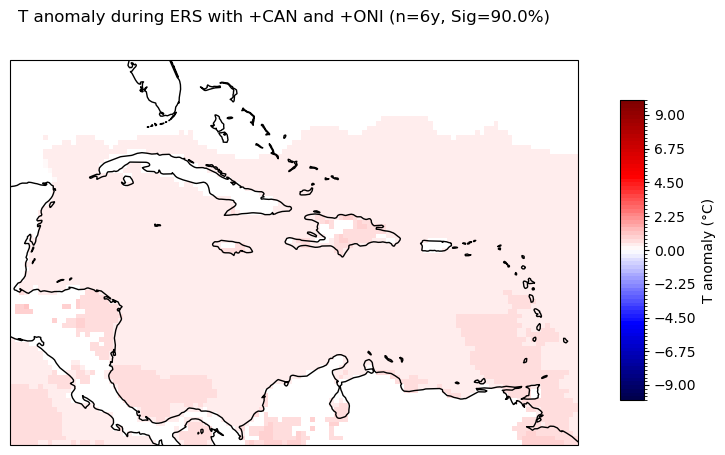

In [67]:
ERS_T_sig_plot = ERS_T_sig_CoPo.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = ERS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(ERS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

ERS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during ERS with +CAN and +ONI (n={CANo_ONIo_ERSy.sizes['time']}y, Sig={sig_threshold*100}%)')

### <span style="color: orange"> LRS <span/>

#### HI and UV

Text(0.5, 0.98, 'Heat Index and surface UV anomalies during LRS with +CAN and +ONI (n=8y, Sig=90.0%)')

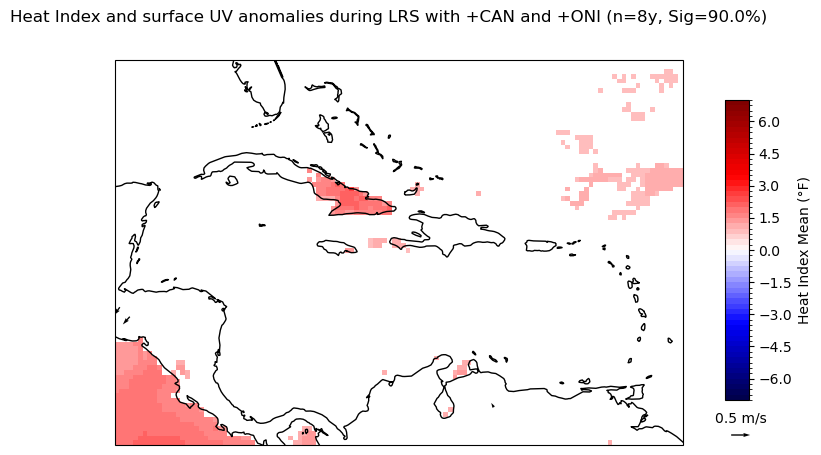

In [68]:
LRS_HI_sig_plot = LRS_HI_sig_CoPo.plot(figsize=(8, 5),levels=np.arange(-7, 7.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)

UV_coarse = LRS_UV_sig_CoPo.isel(longitude=slice(None, None, 2), latitude=slice(None, None, 2))
UV_q = UV_coarse.plot.quiver(x='longitude', y='latitude', u='U', v='V', transform=ccrs.PlateCarree(), add_guide=False, scale=15)

fig = LRS_HI_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_HI_sig_plot, cax=cax, label='Heat Index Mean (°F)', orientation='vertical', extend='neither')
plt.quiverkey(UV_q, X=0.94, Y=0.13, U=0.5, label='0.5 m/s', labelpos='N', coordinates='figure')

LRS_HI_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())

plt.suptitle(f'Heat Index and surface UV anomalies during LRS with +CAN and +ONI (n={CANo_ONIo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### RH

Text(0.5, 0.98, 'RH anomaly during LRS with +CAN and +ONI (n=8y, Sig=90.0%)')

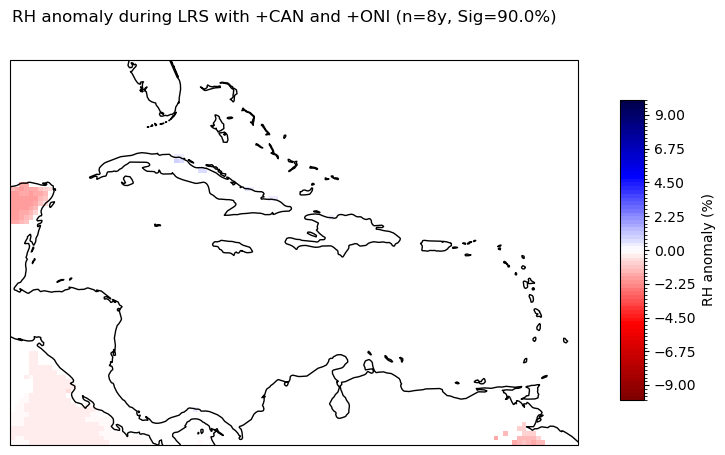

In [69]:
LRS_RH_sig_plot = LRS_RH_sig_CoPo.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic_r', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_RH_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_RH_sig_plot, cax=cax, label='RH anomaly (%)', orientation='vertical', extend='neither')

LRS_RH_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'RH anomaly during LRS with +CAN and +ONI (n={CANo_ONIo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

#### T

Text(0.5, 0.98, 'T anomaly during LRS with +CAN and +ONI (n=8y, Sig=90.0%)')

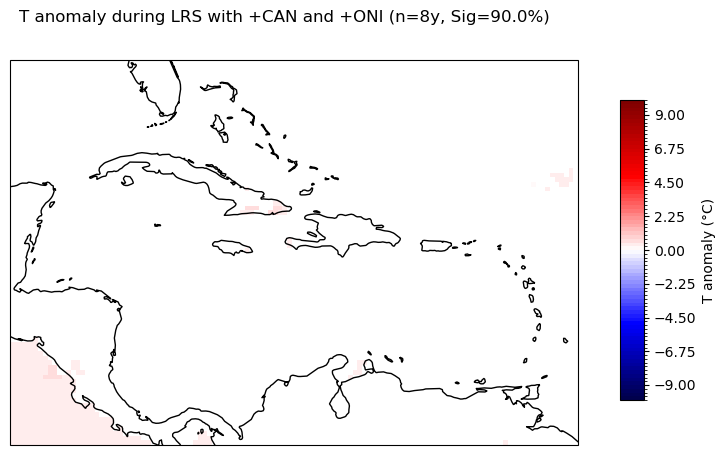

In [70]:
LRS_T_sig_plot = LRS_T_sig_CoPo.plot(figsize=(8, 5),levels=np.arange(-10, 10.25, 0.25), colors='seismic', subplot_kws={'projection': ccrs.PlateCarree()}, add_colorbar=False)


fig = LRS_T_sig_plot.get_figure()
cax = fig.add_axes([0.92, 0.2, 0.03, 0.6])

fig.colorbar(LRS_T_sig_plot, cax=cax, label='T anomaly (°C)', orientation='vertical', extend='neither')

LRS_T_sig_plot.axes.coastlines(transform=ccrs.PlateCarree())
plt.suptitle(f'T anomaly during LRS with +CAN and +ONI (n={CANo_ONIo_LRSy.sizes['time']}y, Sig={sig_threshold*100}%)')

# <span style="color:orange">WarmWarm EAN-ONI<span/>